In [1]:
import torch
import os

# 1. GPU Kontrolü
if not torch.cuda.is_available():
    raise RuntimeError("HATA: GPU bulunamadı! Lütfen 'Runtime > Change runtime type' menüsünden GPU (T4) seçtiğinizden emin olun.")

print(f"✅ GPU Aktif: {torch.cuda.get_device_name(0)}")

# 2. Drive Bağlama
from google.colab import drive
drive.mount("/content/drive")

# 3. Klasör Yolları ve Oluşturma (Tee hatasını çözer)
# Çıktıları Drive'da tutuyoruz ki session kapansa bile model kaybolmasın.
RUN_DIR = "/content/drive/MyDrive/llamafactory_runs"
OUTPUT_DIR = os.path.join(RUN_DIR, "atakan_qa_qwen2.5_lora")
LOG_FILE = os.path.join(RUN_DIR, "training_log.txt")

os.makedirs(RUN_DIR, exist_ok=True)
# Output dir'i LlamaFactory kendi oluşturur ama üst klasörün varlığından emin olduk.

print(f"📂 Çıktı Klasörü: {OUTPUT_DIR}")
print(f"📝 Log Dosyası: {LOG_FILE}")

✅ GPU Aktif: Tesla T4
Mounted at /content/drive
📂 Çıktı Klasörü: /content/drive/MyDrive/llamafactory_runs/atakan_qa_qwen2.5_lora
📝 Log Dosyası: /content/drive/MyDrive/llamafactory_runs/training_log.txt


In [2]:
import os

# W&B'yi tamamen devre dışı bırak
os.environ["WANDB_MODE"] = "disabled"
os.environ["WANDB_DISABLED"] = "true"

# LlamaFactory Kurulumu
!rm -rf LlamaFactory
!git clone --depth 1 https://github.com/hiyouga/LlamaFactory.git
%cd LlamaFactory
!pip install -e ".[torch,metrics]"
!pip install bitsandbytes
!pip install pandas matplotlib

Cloning into 'LlamaFactory'...
remote: Enumerating objects: 518, done.
remote: Counting objects: 100% (518/518), done.
remote: Compressing objects: 100% (400/400), done.
remote: Total 518 (delta 126), reused 342 (delta 82), pack-reused 0 (from 0)
Receiving objects: 100% (518/518), 5.20 MiB | 25.85 MiB/s, done.
Resolving deltas: 100% (126/126), done.
/content/LlamaFactory
Obtaining file:///content/LlamaFactory
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Installing backend dependencies ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 375.8/375.8 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 MB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━

In [3]:
from google.colab import files
import os

# Eğer daha önce yüklediysen sil ki karışmasın
if os.path.exists("/content/dataset.csv"):
    os.remove("/content/dataset.csv")

print("Lütfen 'dataset.csv' dosyanı seç:")
uploaded = files.upload()
filename = next(iter(uploaded))
print(f"✅ Yüklenen dosya: {filename}")

Lütfen 'dataset.csv' dosyanı seç:


Saving dataset.csv to dataset.csv
✅ Yüklenen dosya: dataset.csv


In [6]:
import os
import json
import pandas as pd
from google.colab import files

# --- 1. Dosyayı Bulma ---
possible_paths = ["dataset.csv", "/content/dataset.csv", "/content/LlamaFactory/dataset.csv"]
csv_path = None
for p in possible_paths:
    if os.path.exists(p):
        csv_path = p
        break

if not csv_path:
    print("⚠️ dataset.csv bulunamadı, lütfen seçin:")
    uploaded = files.upload()
    csv_path = next(iter(uploaded))

print(f"✅ Dosya bulundu: {csv_path}")

# --- 2. Akıllı Okuma (Encoding Fix) ---
# Sorunun kaynağı burasıydı: Farklı formatları sırayla deniyoruz
encodings_to_try = ["utf-8", "utf-8-sig", "cp1254", "latin5", "iso-8859-9", "latin-1"]
df = None

for enc in encodings_to_try:
    try:
        # csv_path dosyasını dener
        df = pd.read_csv(csv_path, sep=";", quotechar='"', engine="python", encoding=enc)
        print(f"✅ CSV başarıyla okundu! (Kullanılan format: {enc})")
        break
    except UnicodeDecodeError:
        continue # Bu format uymadı, sonrakini dene
    except Exception as e:
        # Başka bir hataysa (noktalı virgül sorunu vs)
        continue

if df is None:
    raise RuntimeError("❌ Dosya hiçbir formatla (UTF-8, CP1254 vb.) okunamadı. Lütfen dosyayı Excel'de açıp 'Farklı Kaydet > CSV UTF-8 (Virgülle ayrılmış)' seçeneğiyle kaydedip tekrar yükleyin.")

print(f"Sütunlar: {list(df.columns)}")

# --- 3. Veri İşleme ve Kaydetme ---
df.columns = [str(c).lower().strip() for c in df.columns]

# Kolon bulma
col_q = next((c for c in df.columns if "question" in c or "soru" in c), None)
col_a = next((c for c in df.columns if "answer" in c or "cevap" in c), None)

if not col_q or not col_a:
    # İsimden bulamazsa 1. ve 2. sütunu al (Excel bazen ID sütunu ekler, dikkat)
    # Genelde ID;SORU;CEVAP yapısındaysa index 1 ve 2 doğrudur.
    print(f"⚠️ İsimle bulunamadı, 2. ve 3. sütunlar varsayılıyor.")
    col_q = df.columns[1]
    col_a = df.columns[2]

dataset_data = []
for _, row in df.iterrows():
    q = str(row[col_q]).strip()
    a = str(row[col_a]).strip()
    if q and a and q.lower() != 'nan' and a.lower() != 'nan':
        dataset_data.append({"instruction": q, "input": "", "output": a})

JSON_PATH = "/content/LlamaFactory/data/atakan_qa.json"
os.makedirs(os.path.dirname(JSON_PATH), exist_ok=True)

with open(JSON_PATH, 'w', encoding='utf-8') as f:
    json.dump(dataset_data, f, ensure_ascii=False, indent=2)

print(f"✅ JSON hazır: {len(dataset_data)} satır.")

# --- 4. dataset_info.json Güncelleme ---
INFO_PATH = "/content/LlamaFactory/data/dataset_info.json"
if os.path.exists(INFO_PATH):
    with open(INFO_PATH, 'r', encoding='utf-8') as f:
        info = json.load(f)
else:
    info = {}

info["atakan_qa"] = {
    "file_name": "atakan_qa.json",
    "formatting": "alpaca"
}

with open(INFO_PATH, 'w', encoding='utf-8') as f:
    json.dump(info, f, ensure_ascii=False, indent=2)

print("✅ dataset_info.json güncellendi. Devam edebilirsin!")

✅ Dosya bulundu: dataset.csv
✅ CSV başarıyla okundu! (Kullanılan format: cp1254)
Sütunlar: ['id', 'question', 'answer', 'source_doc', 'source_loc', 'tags', 'difficulty']
✅ JSON hazır: 1000 satır.
✅ dataset_info.json güncellendi. Devam edebilirsin!


In [7]:
import textwrap
import os

# Çıktıların kaydedileceği yer (Drive)
OUTPUT_DIR = "/content/drive/MyDrive/llamafactory_runs/atakan_qa_qwen2.5_lora"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Eğitim Ayarları (T4 GPU için optimize edildi)
yaml_content = f"""
### model
model_name_or_path: Qwen/Qwen2.5-3B-Instruct

### method
stage: sft
do_train: true
finetuning_type: lora
lora_target: all
lora_rank: 16
lora_alpha: 32
lora_dropout: 0.05

### dataset
dataset: atakan_qa
template: qwen
cutoff_len: 1024
max_samples: 10000
overwrite_cache: true
preprocessing_num_workers: 16

### output
output_dir: {OUTPUT_DIR}
logging_steps: 10
save_steps: 100
plot_loss: true
overwrite_output_dir: true

### train
per_device_train_batch_size: 1
gradient_accumulation_steps: 8
learning_rate: 2.0e-4
num_train_epochs: 3.0
lr_scheduler_type: cosine
warmup_ratio: 0.1
fp16: true

### quantization (4-bit QLoRA)
quantization_bit: 4
quantization_method: bitsandbytes

### evaluation
val_size: 0.1
per_device_eval_batch_size: 1
eval_strategy: steps
eval_steps: 100
"""

config_path = "/content/train_config.yaml"
with open(config_path, "w", encoding="utf-8") as f:
    f.write(textwrap.dedent(yaml_content).strip())

print(f"✅ Config dosyası hazır: {config_path}")
print(f"📂 Çıktılar şuraya gidecek: {OUTPUT_DIR}")

✅ Config dosyası hazır: /content/train_config.yaml
📂 Çıktılar şuraya gidecek: /content/drive/MyDrive/llamafactory_runs/atakan_qa_qwen2.5_lora


In [8]:
%cd /content/LlamaFactory
# Log dosyasını hem ekrana hem dosyaya yazmak için tee kullanıyoruz
!llamafactory-cli train /content/train_config.yaml 2>&1 | tee "/content/drive/MyDrive/llamafactory_runs/training_log.txt"

/content/LlamaFactory
2026-01-15 19:50:46.834191: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768506646.854556    2262 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768506646.860660    2262 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1768506646.875870    2262 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768506646.875894    2262 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768506646.875897    2262 computation_placer.cc:177] 

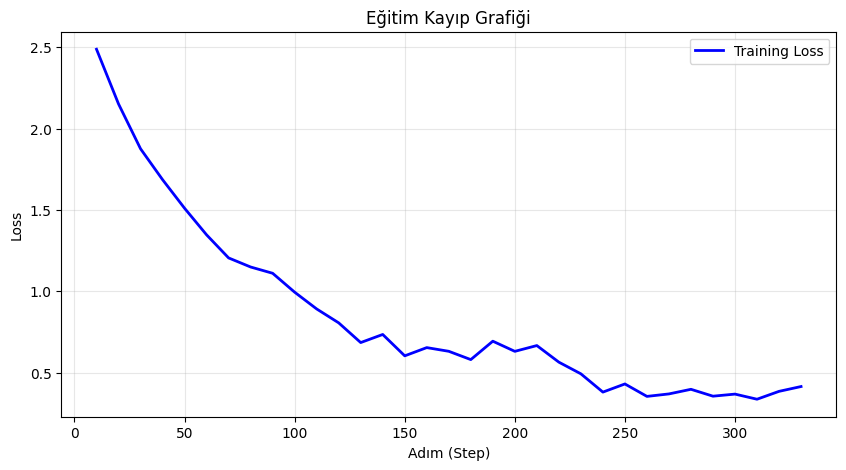

In [9]:
import json
import matplotlib.pyplot as plt
import os

# Log dosyasını bul (LlamaFactory genelde output klasörüne trainer_log.jsonl atar)
OUTPUT_DIR = "/content/drive/MyDrive/llamafactory_runs/atakan_qa_qwen2.5_lora"
trainer_log_path = os.path.join(OUTPUT_DIR, "trainer_log.jsonl")

steps, losses = [], []

if os.path.exists(trainer_log_path):
    with open(trainer_log_path, "r") as f:
        for line in f:
            try:
                data = json.loads(line)
                if "loss" in data:
                    # step bazen 'current_steps' veya 'step' olabilir
                    step = data.get("current_steps") or data.get("step")
                    if step:
                        steps.append(step)
                        losses.append(data["loss"])
            except:
                pass

    if steps:
        plt.figure(figsize=(10, 5))
        plt.plot(steps, losses, label="Training Loss", color="blue", linewidth=2)
        plt.xlabel("Adım (Step)")
        plt.ylabel("Loss")
        plt.title("Eğitim Kayıp Grafiği")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()
    else:
        print("⚠️ Log dosyasında henüz çizilecek veri yok (Eğitim yeni başlamış olabilir).")
else:
    print(f"⚠️ Log dosyası henüz oluşmamış: {trainer_log_path}")

📉 Eğitim Kayıp Grafiği:


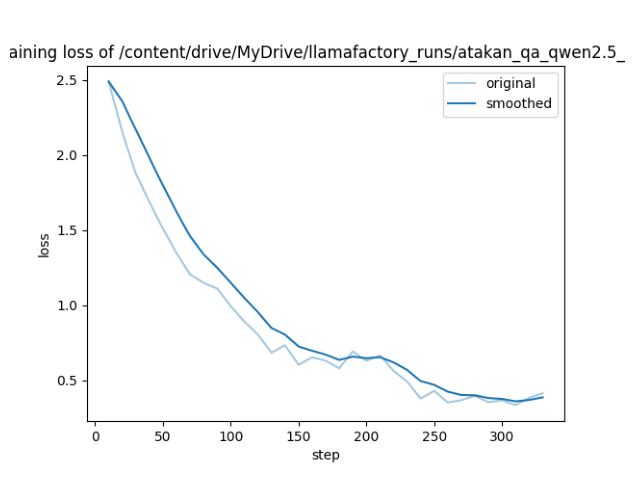

In [11]:
from PIL import Image
import os
import matplotlib.pyplot as plt

# Loglarda belirtilen kayıt yolu
OUTPUT_DIR = "/content/drive/MyDrive/llamafactory_runs/atakan_qa_qwen2.5_lora"
loss_plot_path = os.path.join(OUTPUT_DIR, "training_loss.png")
eval_plot_path = os.path.join(OUTPUT_DIR, "training_eval_loss.png")

if os.path.exists(loss_plot_path):
    print("📉 Eğitim Kayıp Grafiği:")
    img = Image.open(loss_plot_path)
    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.show()
else:
    print("Grafik dosyası bulunamadı, ancak eğitim tamamlandı.")

In [12]:
import gradio as gr
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel
import os

# --- Ayarlar ---
BASE_MODEL_ID = "Qwen/Qwen2.5-3B-Instruct"
# Loglardan aldığımız kesin yol:
ADAPTER_PATH = "/content/drive/MyDrive/llamafactory_runs/atakan_qa_qwen2.5_lora"

print("⏳ Model ve Adaptör yükleniyor... (Bu işlem 1-2 dakika sürebilir)")

# 1. Base Modeli Yükle (4-bit)
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_ID, trust_remote_code=True)
base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_ID,
    device_map="auto",
    torch_dtype=torch.float16,
    load_in_4bit=True,
    trust_remote_code=True
)

# 2. Senin Eğittiğin LoRA Adaptörünü Yükle
if os.path.exists(ADAPTER_PATH):
    model = PeftModel.from_pretrained(base_model, ADAPTER_PATH)
    model.eval()
    print("✅ Fine-tuned model başarıyla yüklendi! Hazırsın.")
else:
    raise FileNotFoundError(f"Adaptör bulunamadı: {ADAPTER_PATH}")

# 3. Chat Fonksiyonu
def chat_logic(soru, temperature, max_tokens):
    messages = [
        {"role": "system", "content": "Sen Fırat Üniversitesi akademik teşvik yönetmeliği konusunda uzman bir asistansın. Cevapları sadece yönetmelik ve başvuru rehberine dayanarak, resmi ve net bir dille ver."},
        {"role": "user", "content": soru}
    ]

    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer([prompt], return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=int(max_tokens),
            temperature=float(temperature),
            top_p=0.9
            # repetition_penalty eklenebilir eğer tekrar ederse
        )

    generated_ids = [
        output_ids[len(input_ids):] for input_ids, output_ids in zip(inputs.input_ids, outputs)
    ]
    response = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]
    return response

# 4. Arayüz
demo = gr.Interface(
    fn=chat_logic,
    inputs=[
        gr.Textbox(label="Sorunuz", placeholder="Örn: Atıf puanı nasıl hesaplanır?", lines=2),
        gr.Slider(0.1, 1.0, value=0.1, label="Yaratıcılık (Temperature - Düşük olması daha iyidir)"),
        gr.Slider(64, 1024, value=512, label="Maksimum Uzunluk")
    ],
    outputs=gr.Textbox(label="Cevap", lines=10),
    title="🎓 Akademik Teşvik Asistanı",
    description="Qwen-2.5-3B + LoRA (Atakan QA Dataset)"
)

demo.launch(share=True, debug=True)

⏳ Model ve Adaptör yükleniyor... (Bu işlem 1-2 dakika sürebilir)


The `load_in_4bit` and `load_in_8bit` arguments are deprecated and will be removed in the future versions. Please, pass a `BitsAndBytesConfig` object in `quantization_config` argument instead.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

✅ Fine-tuned model başarıyla yüklendi! Hazırsın.
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://df0266a727e9794bad.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://df0266a727e9794bad.gradio.live
